# Oxford Kokam — Outlier QC, Reference Curves, OCV Deformation Descriptors

**Manuscript:** *Aging-Driven Open-Circuit Voltage Deformation Across Lithium-Ion Battery Datasets: Transferable Descriptors for Health-Aware Battery Management*

This notebook is the second step of the Oxford pipeline. The first notebook (`Oxford_Download_and_Parse.ipynb`) produced `oxford_pseudo_ocv.parquet` and `oxford_capacity_fade.parquet`. Here we:

1. **§4.1 QC** — flag and remove outlier characterization points on the capacity-fade trajectory (Cell5 jump at cycle 5000, Cell2 dip at cycle 7400)
2. **§3.3** — define per-cell **near-pristine reference curve** $U_\text{ref}(\text{SOC}) = \bar{U}(\text{SOC}, \text{SOH} \ge 0.99)$
3. **§3.3** — compute deformation profiles $\Delta U(\text{SOC}, \text{SOH})$ for all 8 cells × all aging states
4. **§3.4** — extract the six descriptors per (cell, aging state):
   - D1: Mean voltage drift
   - D2: SOC-local voltage drift profile
   - D3: Plateau shift (relative-slope-percentile threshold, §3.4.3 form for non-LFP chemistry)
   - D4: Slope amplification profile
   - D5: Differential-voltage signature + peak position
   - D6: Normalized Deformation Index (NDI, range-normalized)
5. **§3.5** — Fit a Gaussian Process on the **pooled per-cell** (SOC, SOH) → U surface with anisotropic Matérn kernel; leave-one-SOH-out validation
6. **§3.6** — Propagate posterior uncertainty to NDI, plateau center, slope amplification via posterior sampling

Outputs (written to `processed/`):

| File | Contents |
|------|----------|
| `oxford_qc_flags.parquet`           | per (cell, cycle) outlier flags + reason |
| `oxford_reference_curves.parquet`   | $U_\text{ref}(\text{SOC})$ per cell |
| `oxford_deformation_profiles.parquet` | long-format $\Delta U(\text{SOC}, \text{SOH})$ |
| `oxford_descriptors.parquet`        | scalar descriptors D1, D6 + summary stats |
| `oxford_descriptors_local.parquet`  | SOC-resolved D2, D4, D5 profiles |
| `oxford_gp_metrics.csv`             | LOSO validation metrics per cell |
| `oxford_descriptors_with_uncertainty.parquet` | descriptors with 95% CIs from GP posterior |


## 0. Environment setup

In [ ]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator
from scipy.signal import find_peaks
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (Matern, ConstantKernel as C,
                                              WhiteKernel)

warnings.filterwarnings('ignore', category=UserWarning)

IBM = ['#648FFF', '#785EF0', '#DC267F', '#FE6100', '#FFB000',
       '#009E73', '#56B4E9', '#000000']

plt.rcParams.update({
    'font.size': 11, 'axes.grid': True, 'grid.alpha': 0.3,
    'figure.dpi': 110, 'savefig.dpi': 200, 'savefig.bbox': 'tight',
})

RNG = np.random.default_rng(20260101)  # deterministic GP posterior sampling

print(f"NumPy   : {np.__version__}")
print(f"Pandas  : {pd.__version__}")

NumPy   : 2.0.2
Pandas  : 2.2.2


## 1. Mount Drive and load processed Oxford data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_ROOT = Path('/content/drive/MyDrive/Colab Notebooks/Battery Data')
OXFORD_DIR = DRIVE_ROOT / 'Oxford Battery Degradation Dataset 1'
INPUT_DIR  = OXFORD_DIR / 'processed'
FIGURE_DIR = OXFORD_DIR / 'figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

cap_df = pd.read_parquet(INPUT_DIR / 'oxford_capacity_fade.parquet')
ocv_df = pd.read_parquet(INPUT_DIR / 'oxford_pseudo_ocv.parquet')

print(f"Capacity fade rows : {len(cap_df)}")
print(f"Pseudo-OCV rows    : {len(ocv_df)}")
print(f"Cells              : {sorted(ocv_df['cell_id'].unique())}")
print()
print(cap_df.head().to_string(index=False))

Mounted at /content/drive
Capacity fade rows : 519
Pseudo-OCV rows    : 51381
Cells              : ['Cell1', 'Cell2', 'Cell3', 'Cell4', 'Cell5', 'Cell6', 'Cell7', 'Cell8']

cell_id cycle_key  cycle_number  capacity_ah      soh
  Cell1   cyc0000             0     0.739111 1.000000
  Cell1   cyc0100           100     0.730193 0.987934
  Cell1   cyc0200           200     0.725747 0.981919
  Cell1   cyc0300           300     0.722843 0.977990
  Cell1   cyc0400           400     0.718367 0.971934


## 2. §4.1 Quality control on the capacity-fade trajectory

The capacity-fade plot showed two clear characterization-point anomalies:
- **Cell5** at cycle ≈ 5000: SOH drops to 0.62 in a single step (true fade trajectory of comparable cells is ≈ 0.78 at that point)
- **Cell2** at cycle ≈ 7400: SOH dips to 0.68 then recovers to 0.78

These are characterization-measurement anomalies (likely incomplete pseudo-OCV, sensor drift, or partial discharge), not real capacity loss. If left in, they would produce pathological descriptor values at those aging states.

**Filter:** rolling-median residual rejection per cell. For each cell, compute a centered rolling median of SOH over a 5-point window. Flag a point if its residual exceeds $\lambda \cdot \text{MAD}$ of the local residuals.


In [ ]:
def qc_capacity_fade(df, window=7, lam=6.0, max_consec_flagged=3,
                     abs_resid_floor=0.005):
    """Hampel-style outlier rejection on SOH trajectory per cell.

    Refinements:
      1. Always protect cyc0000 (reference point; no left-side neighbours).
      2. λ = 6 (conservative — only obvious anomalies).
      3. Un-flag long consecutive runs (knee-point fade is real, not anomaly).
      4. Absolute residual floor: if |SOH - rolling_median| < abs_resid_floor
         (default 0.5% SOH ≈ measurement noise floor), never flag. This
         prevents the filter from flagging pairs of near-identical SOH
         points where MAD itself collapses to a value below noise level.
      5. Monotonicity-break check: SOH cannot increase by > 0.02 between
         consecutive accepted points (no spontaneous capacity recovery).
    """
    out = df.copy()
    out['soh_med'] = np.nan
    out['soh_resid'] = np.nan
    out['qc_outlier'] = False
    out['qc_reason']  = ''

    for cid, g in out.groupby('cell_id'):
        g = g.sort_values('cycle_number')
        med = g['soh'].rolling(window, center=True, min_periods=1).median()
        resid = (g['soh'] - med).values
        mad = np.nanmedian(np.abs(resid - np.nanmedian(resid))) + 1e-9

        # MAD-based flag
        outlier = np.abs(resid) > lam * mad

        # Absolute residual floor: ignore deviations below measurement noise
        outlier &= np.abs(resid) > abs_resid_floor

        # Protect cyc0000
        is_zero = (g['cycle_number'].values == 0)
        outlier[is_zero] = False

        # Un-flag long consecutive runs (real fade acceleration)
        i = 0
        while i < len(outlier):
            if outlier[i]:
                j = i
                while j < len(outlier) and outlier[j]:
                    j += 1
                if (j - i) > max_consec_flagged:
                    outlier[i:j] = False
                i = j
            else:
                i += 1

        # Monotonicity-break check
        soh_vals = g['soh'].values
        nonmono = np.zeros(len(g), dtype=bool)
        prev_accepted = soh_vals[0]
        for k in range(1, len(soh_vals)):
            if not outlier[k]:
                if soh_vals[k] > prev_accepted + 0.02:
                    nonmono[k] = True
                else:
                    prev_accepted = soh_vals[k]
        nonmono[is_zero] = False

        final = outlier | nonmono
        reasons = np.where(outlier, 'MAD-residual',
                  np.where(nonmono, 'non-monotonic', ''))

        out.loc[g.index, 'soh_med']   = med.values
        out.loc[g.index, 'soh_resid'] = resid
        out.loc[g.index, 'qc_outlier'] = final
        out.loc[g.index, 'qc_reason'] = reasons
    return out


qc_df = qc_capacity_fade(cap_df, window=7, lam=6.0,
                         max_consec_flagged=3, abs_resid_floor=0.005)

flagged = qc_df[qc_df['qc_outlier']]
print(f"Total characterization points : {len(qc_df)}")
print(f"Flagged as outliers           : {len(flagged)}")
print()
if len(flagged):
    print("Flagged points:")
    print(flagged[['cell_id', 'cycle_number', 'soh',
                   'soh_med', 'qc_reason']].to_string(index=False))

qc_df.to_parquet(INPUT_DIR / 'oxford_qc_flags.parquet', index=False)

Total characterization points : 519
Flagged as outliers           : 15

Flagged points:
cell_id  cycle_number      soh  soh_med    qc_reason
  Cell1           100 0.987934 0.981919 MAD-residual
  Cell2           100 0.988845 0.982769 MAD-residual
  Cell2          5000 0.769844 0.790506 MAD-residual
  Cell2          7400 0.682393 0.757857 MAD-residual
  Cell2          7500 0.765132 0.758013 MAD-residual
  Cell2          7700 0.741563 0.750897 MAD-residual
  Cell3           100 0.988529 0.983150 MAD-residual
  Cell4           100 0.988576 0.981535 MAD-residual
  Cell5           100 0.987749 0.981340 MAD-residual
  Cell5          5000 0.620300 0.825702 MAD-residual
  Cell6           100 0.988932 0.982510 MAD-residual
  Cell6          4600 0.799739 0.810556 MAD-residual
  Cell6          5000 0.790157 0.799970 MAD-residual
  Cell7           100 0.988476 0.982803 MAD-residual
  Cell8           100 0.989713 0.980632 MAD-residual


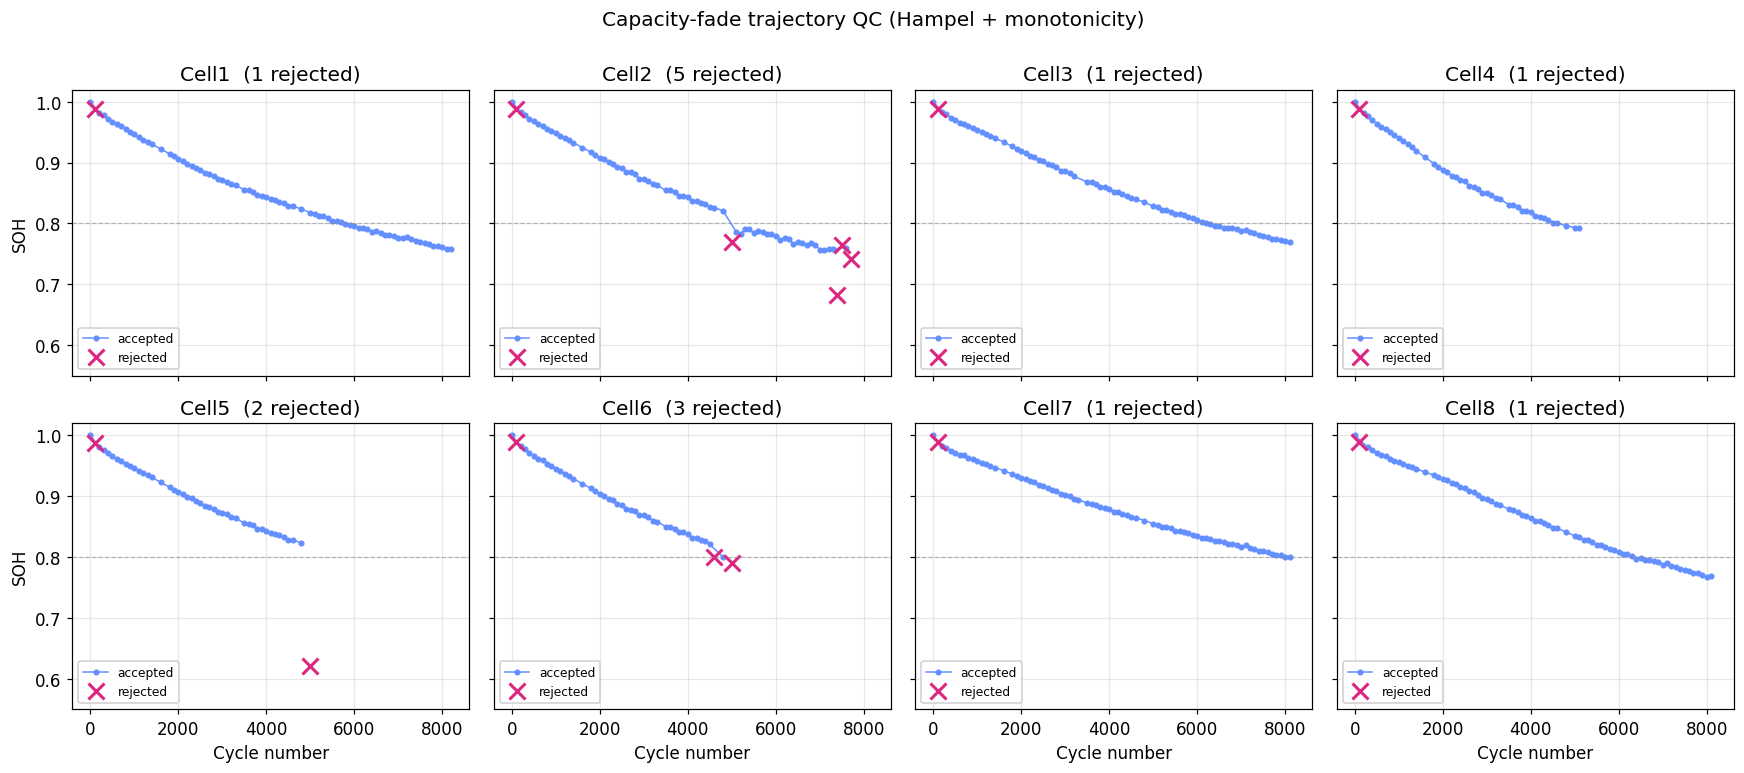

In [ ]:
# Visualize QC: raw vs filtered trajectory
fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharex=True, sharey=True)
for ax, (cid, g) in zip(axes.ravel(), qc_df.groupby('cell_id')):
    g = g.sort_values('cycle_number')
    good = g[~g['qc_outlier']]
    bad  = g[g['qc_outlier']]
    ax.plot(good['cycle_number'], good['soh'], 'o-', color=IBM[0],
            markersize=3, linewidth=1.0, label='accepted')
    if len(bad):
        ax.plot(bad['cycle_number'], bad['soh'], 'x', color=IBM[2],
                markersize=10, markeredgewidth=2.0, label='rejected')
    ax.axhline(0.8, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)
    ax.set_title(f'{cid}  ({len(bad)} rejected)')
    ax.set_ylim(0.55, 1.02)
    ax.legend(loc='lower left', fontsize=8, framealpha=0.92)

for ax in axes[-1]:
    ax.set_xlabel('Cycle number')
for ax in axes[:, 0]:
    ax.set_ylabel('SOH')

fig.suptitle('Capacity-fade trajectory QC (Hampel + monotonicity)', y=1.00)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'fig_oxford_qc_capacity_fade.png')
plt.show()

## 3. Filter and merge QC'd OCV data

We drop OCV rows whose (cell, cycle) was rejected, then keep a single SOH value per (cell, cycle) by averaging within the group (numerically identical for our data, just defensive). The result is the **clean working table** for all downstream §3.3–§3.6 steps.

In [ ]:
rejected_keys = set(
    (r.cell_id, r.cycle_key)
    for r in qc_df[qc_df['qc_outlier']].itertuples()
)
print(f"Rejected (cell, cycle) keys: {len(rejected_keys)}")

mask = ~ocv_df.apply(lambda r: (r['cell_id'], r['cycle_key']) in rejected_keys, axis=1)
ocv_clean = ocv_df[mask].copy()

print(f"Pseudo-OCV rows  before QC : {len(ocv_df)}")
print(f"Pseudo-OCV rows  after  QC : {len(ocv_clean)}")
print(f"Distinct (cell, cycle)     : "
      f"{ocv_clean.groupby(['cell_id', 'cycle_key']).ngroups}")

SOC_GRID = np.sort(ocv_clean['soc'].unique())
N_SOC = len(SOC_GRID)
print(f"SOC grid size              : {N_SOC}  "
      f"(range {SOC_GRID.min():.2f} – {SOC_GRID.max():.2f})")

Rejected (cell, cycle) keys: 15
Pseudo-OCV rows  before QC : 51381
Pseudo-OCV rows  after  QC : 49896
Distinct (cell, cycle)     : 504
SOC grid size              : 99  (range 0.01 – 0.99)


## 4. §3.3 Near-pristine reference curve per cell

Per cell, the reference curve is the **average pseudo-OCV across early-life states with SOH ≥ 0.99**. Averaging across (typically) 2–4 early-life characterizations rather than a single $\text{SOH}=1$ point reduces measurement noise (manuscript §3.3).

$$U_\text{ref}(\text{SOC}) = \frac{1}{K} \sum_{k:\, \text{SOH}_k \ge 0.99} U(\text{SOC}, \text{SOH}_k)$$


In [ ]:
def build_reference_curves(ocv_clean, qc_df, soh_threshold=0.99):
    """Per-cell near-pristine reference curve (manuscript §3.3)."""
    qc_good = qc_df[~qc_df['qc_outlier']]
    refs = []
    for cid, g in qc_good.groupby('cell_id'):
        early = g[g['soh'] >= soh_threshold]
        if len(early) < 1:
            # fall back to the single highest-SOH point
            early = g.nlargest(1, 'soh')
        early_keys = set(early['cycle_key'])

        sub = ocv_clean[
            (ocv_clean['cell_id'] == cid) &
            (ocv_clean['cycle_key'].isin(early_keys))
        ]
        # average per SOC across the early-life characterizations
        ref = sub.groupby('soc')['voltage'].mean().reset_index()
        ref['cell_id'] = cid
        ref['n_curves_averaged'] = len(early_keys)
        refs.append(ref)

    ref_df = pd.concat(refs, ignore_index=True)
    return ref_df[['cell_id', 'soc', 'voltage', 'n_curves_averaged']]


ref_df = build_reference_curves(ocv_clean, qc_df, soh_threshold=0.99)
ref_df.to_parquet(INPUT_DIR / 'oxford_reference_curves.parquet', index=False)

n_averaged_summary = (ref_df.groupby('cell_id')['n_curves_averaged']
                            .first()
                            .reset_index()
                            .rename(columns={'n_curves_averaged': 'K_early'}))
print(n_averaged_summary.to_string(index=False))
print(f"\nReference table rows: {len(ref_df)}  "
      f"({ref_df['cell_id'].nunique()} cells × {N_SOC} SOC points)")

cell_id  K_early
  Cell1        1
  Cell2        1
  Cell3        1
  Cell4        1
  Cell5        1
  Cell6        1
  Cell7        1
  Cell8        1

Reference table rows: 792  (8 cells × 99 SOC points)


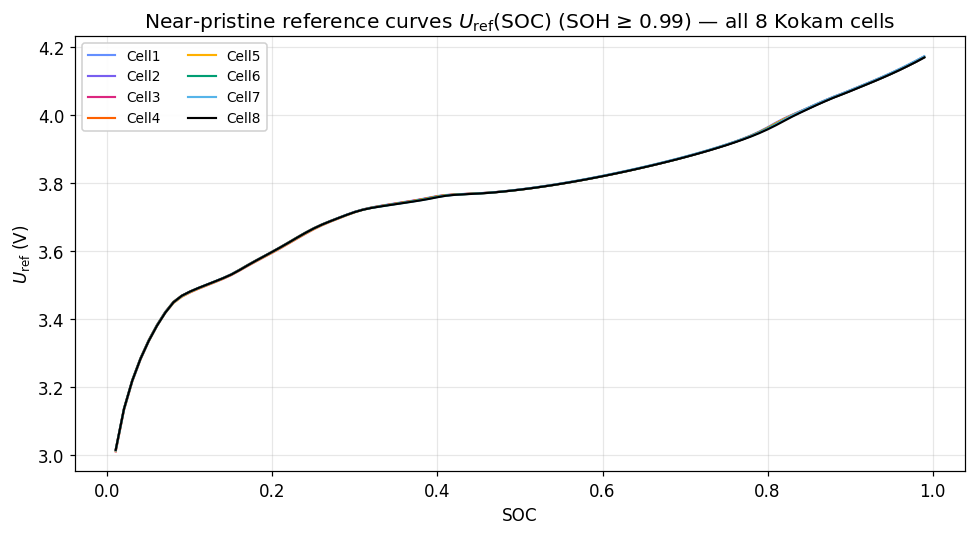

Cross-cell reference voltage range (max - min, mV):  median = 2.54,  max = 7.86


In [ ]:
# Reference curve overlay across cells
fig, ax = plt.subplots(figsize=(9, 5))
for i, (cid, g) in enumerate(ref_df.groupby('cell_id')):
    g = g.sort_values('soc')
    ax.plot(g['soc'], g['voltage'], color=IBM[i % len(IBM)],
            label=cid, linewidth=1.4)
ax.set_xlabel('SOC')
ax.set_ylabel(r'$U_\mathrm{ref}$ (V)')
ax.set_title(r'Near-pristine reference curves $U_\mathrm{ref}(\mathrm{SOC})$ '
             '(SOH ≥ 0.99) — all 8 Kokam cells')
ax.legend(loc='best', fontsize=9, ncol=2, framealpha=0.92)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'fig_oxford_reference_curves.png')
plt.show()

# Cross-cell spread at each SOC: tells us how close the 8 Kokam cells are at SOH=1
spread = (ref_df.groupby('soc')['voltage']
                .agg(['mean', 'std', 'min', 'max'])
                .reset_index())
spread['range_mv'] = (spread['max'] - spread['min']) * 1000
print(f"Cross-cell reference voltage range "
      f"(max - min, mV):  median = {spread['range_mv'].median():.2f},  "
      f"max = {spread['range_mv'].max():.2f}")

## 5. §3.3 Deformation profiles $\Delta U(\text{SOC}, \text{SOH})$

For each (cell, aging state) we subtract the cell's own reference curve:

$$\Delta U(\text{SOC}, \text{SOH}) = U(\text{SOC}, \text{SOH}) - U_\text{ref}^{\text{(cell)}}(\text{SOC})$$

This is the central transformation of the paper (manuscript §3.3, page 14). All downstream descriptors operate on $\Delta U$.

In [ ]:
# Merge in the reference and compute ΔU
ref_lookup = ref_df.rename(columns={'voltage': 'voltage_ref'})[
    ['cell_id', 'soc', 'voltage_ref']
]
defo_df = ocv_clean.merge(ref_lookup, on=['cell_id', 'soc'], how='left')
defo_df['delta_u'] = defo_df['voltage'] - defo_df['voltage_ref']

# Sanity: ΔU at the reference SOH should be ≈ 0 (averaging noise only)
ref_check = defo_df[defo_df['soh'] >= 0.99]
print(f"ΔU at SOH≥0.99 — mean: {ref_check['delta_u'].mean()*1000:+.3f} mV, "
      f"RMS: {np.sqrt((ref_check['delta_u']**2).mean())*1000:.3f} mV")

defo_df.to_parquet(INPUT_DIR / 'oxford_deformation_profiles.parquet',
                   index=False)
print(f"\nDeformation table rows: {len(defo_df)}")

ΔU at SOH≥0.99 — mean: +0.000 mV, RMS: 0.000 mV

Deformation table rows: 49896


## 6. §3.4 Descriptor extraction

For each (cell, aging state) we compute six descriptors. Five operate per-curve as scalars; D2/D4/D5 also keep SOC-resolved profiles for §4.4–§4.5 figures.

| ID | Descriptor | Form | Equation |
|----|-----------|------|----------|
| D1 | Mean voltage drift | scalar | $D_\text{mean} = \frac{1}{N}\sum_i \Delta U_i$ |
| D2 | SOC-local drift | profile | $D_\text{local}(\text{SOC}) = \Delta U(\text{SOC})$ |
| D3 | Plateau center, width, shift | scalar | rel. slope-percentile threshold (manuscript §3.4.3) |
| D4 | Slope amplification | profile + scalar | $A_\text{slope} = \|\partial U/\partial \text{SOC}\| / (\|\partial U_\text{ref}/\partial \text{SOC}\| + \delta)$ |
| D5 | DV peak position + amplitude | scalar | $\text{SOC}_\text{peak} = \arg\max_\text{SOC} \|dU/d\text{SOC}\|$ |
| D6 | NDI (range-normalized) | scalar | $\|\Delta U\|_2 / (U_\text{ref,max} - U_\text{ref,min})$ |

In [ ]:
DELTA_SLOPE_REG = 1e-4    # regularization for Aslope denominator (§3.4.4)
PLATEAU_PERCENTILE = 30   # qp for relative slope-percentile threshold (§3.4.3)


def compute_slope(soc, u):
    """Numerical derivative dU/dSOC on a (possibly non-uniform) grid."""
    return np.gradient(u, soc)


def compute_plateau_region(soc, u, percentile=PLATEAU_PERCENTILE):
    """§3.4.3: plateau = SOC points where |dU/dSOC| < q_p of the slope distribution."""
    slope = np.abs(compute_slope(soc, u))
    if not np.all(np.isfinite(slope)):
        return np.nan, np.nan, None
    eps = np.percentile(slope, percentile)
    mask = slope < eps
    if mask.sum() < 2:
        return np.nan, np.nan, None
    soc_in = soc[mask]
    return float(soc_in.mean()), float(soc_in.max() - soc_in.min()), mask


def compute_descriptors_for_curve(soc, u, u_ref):
    """All six descriptors for one (cell, SOH) curve."""
    delta = u - u_ref
    u_range = np.nanmax(u_ref) - np.nanmin(u_ref)

    # D1: mean voltage drift
    d_mean = float(np.nanmean(delta))
    d_mean_norm = d_mean / u_range if u_range > 0 else np.nan

    # D2: SOC-local drift profile -- returned alongside as `delta`

    # D3: plateau center / width / shift
    plat_center, plat_width, _ = compute_plateau_region(soc, u)
    plat_ref_center, plat_ref_width, _ = compute_plateau_region(soc, u_ref)
    plat_shift = (plat_center - plat_ref_center
                  if np.isfinite(plat_center) and np.isfinite(plat_ref_center)
                  else np.nan)

    # D4: slope amplification (profile + mean)
    slope = np.abs(compute_slope(soc, u))
    slope_ref = np.abs(compute_slope(soc, u_ref))
    a_slope = slope / (slope_ref + DELTA_SLOPE_REG)
    a_slope_mean = float(np.nanmean(a_slope))

    # D5: peak of |ΔU| signature (manuscript §3.4.5 — track aging-induced
    # peak migration, not the raw dU/dSOC magnitude which is dominated by
    # the low-SOC edge slope and gives no migration information).
    abs_delta = np.abs(delta)
    edge = max(2, int(0.10 * len(soc)))   # ignore 10% on each end
    interior = slice(edge, -edge)
    soc_int = soc[interior]
    abs_delta_int = abs_delta[interior]
    if np.all(np.isnan(abs_delta_int)) or np.nanmax(abs_delta_int) == 0:
        dv_peak_soc, dv_peak_amp = np.nan, np.nan
    else:
        dv_peak_idx = int(np.nanargmax(abs_delta_int))
        dv_peak_soc = float(soc_int[dv_peak_idx])
        dv_peak_amp = float(delta[interior][dv_peak_idx])  # signed
    # Also keep dU/dSOC profile for §4.4 figures
    dv = compute_slope(soc, u)

    # D6: NDI -- range-normalized L2 norm of ΔU (manuscript Eq. NDI_R)
    delta_finite = delta[np.isfinite(delta)]
    l2 = float(np.sqrt(np.sum(delta_finite ** 2)))
    ndi_r = l2 / u_range if u_range > 0 else np.nan
    ndi_rms = (float(np.sqrt(np.mean(delta_finite ** 2))) / u_range
               if u_range > 0 else np.nan)

    return {
        'd1_mean_drift_v'   : d_mean,
        'd1_mean_drift_norm': d_mean_norm,
        'd3_plateau_center' : plat_center,
        'd3_plateau_width'  : plat_width,
        'd3_plateau_shift'  : plat_shift,
        'd4_a_slope_mean'   : a_slope_mean,
        'd5_peak_soc'       : dv_peak_soc,
        'd5_peak_amp_v'     : dv_peak_amp,
        'd6_ndi_r'          : ndi_r,
        'd6_ndi_rms'        : ndi_rms,
    }, delta, a_slope, dv


# Build descriptor table
scalar_rows = []
local_rows  = []

for (cid, ck), g in defo_df.groupby(['cell_id', 'cycle_key']):
    g = g.sort_values('soc')
    soc = g['soc'].values
    u   = g['voltage'].values
    u_ref = g['voltage_ref'].values

    if not (np.all(np.isfinite(u)) and np.all(np.isfinite(u_ref))):
        continue

    descs, delta, a_slope, dv = compute_descriptors_for_curve(soc, u, u_ref)
    soh_val = float(g['soh'].iloc[0])
    cyc_num = int(g['cycle_number'].iloc[0])

    scalar_rows.append({
        'cell_id': cid, 'cycle_key': ck,
        'cycle_number': cyc_num, 'soh': soh_val,
        **descs,
    })

    for s, dl, ai, dvi in zip(soc, delta, a_slope, dv):
        local_rows.append({
            'cell_id': cid, 'cycle_key': ck,
            'cycle_number': cyc_num, 'soh': soh_val, 'soc': float(s),
            'd2_local_drift': float(dl) if np.isfinite(dl) else np.nan,
            'd4_a_slope'    : float(ai) if np.isfinite(ai) else np.nan,
            'd5_dv'         : float(dvi) if np.isfinite(dvi) else np.nan,
        })

desc_df  = pd.DataFrame(scalar_rows)
local_df = pd.DataFrame(local_rows)

desc_df.to_parquet(INPUT_DIR / 'oxford_descriptors.parquet', index=False)
local_df.to_parquet(INPUT_DIR / 'oxford_descriptors_local.parquet', index=False)

print(f"Scalar descriptors : {len(desc_df)} rows  "
      f"({desc_df['cell_id'].nunique()} cells, "
      f"{desc_df.groupby('cell_id').size().mean():.1f} avg states/cell)")
print(f"Local descriptors  : {len(local_df)} rows")
print()
print(desc_df.describe().T[['mean', 'std', 'min', 'max']].to_string())

Scalar descriptors : 504 rows  (8 cells, 63.0 avg states/cell)
Local descriptors  : 49896 rows

                           mean          std       min          max
cycle_number        3667.460317  2269.771250  0.000000  8200.000000
soh                    0.868885     0.064756  0.756937     1.000000
d1_mean_drift_v        0.016610     0.007761  0.000000     0.030865
d1_mean_drift_norm     0.014350     0.006709  0.000000     0.026649
d3_plateau_center      0.423499     0.020473  0.342333     0.465000
d3_plateau_width       0.334504     0.036231  0.290000     0.430000
d3_plateau_shift      -0.041501     0.020473 -0.122667     0.000000
d4_a_slope_mean        1.106939     0.044127  0.999825     1.174195
d5_peak_soc            0.162238     0.019354  0.140000     0.210000
d5_peak_amp_v          0.062863     0.029620  0.004777     0.120992
d6_ndi_r               0.219836     0.101112  0.000000     0.410105
d6_ndi_rms             0.022094     0.010162  0.000000     0.041217


## 7. Descriptor figures (preview for §4)

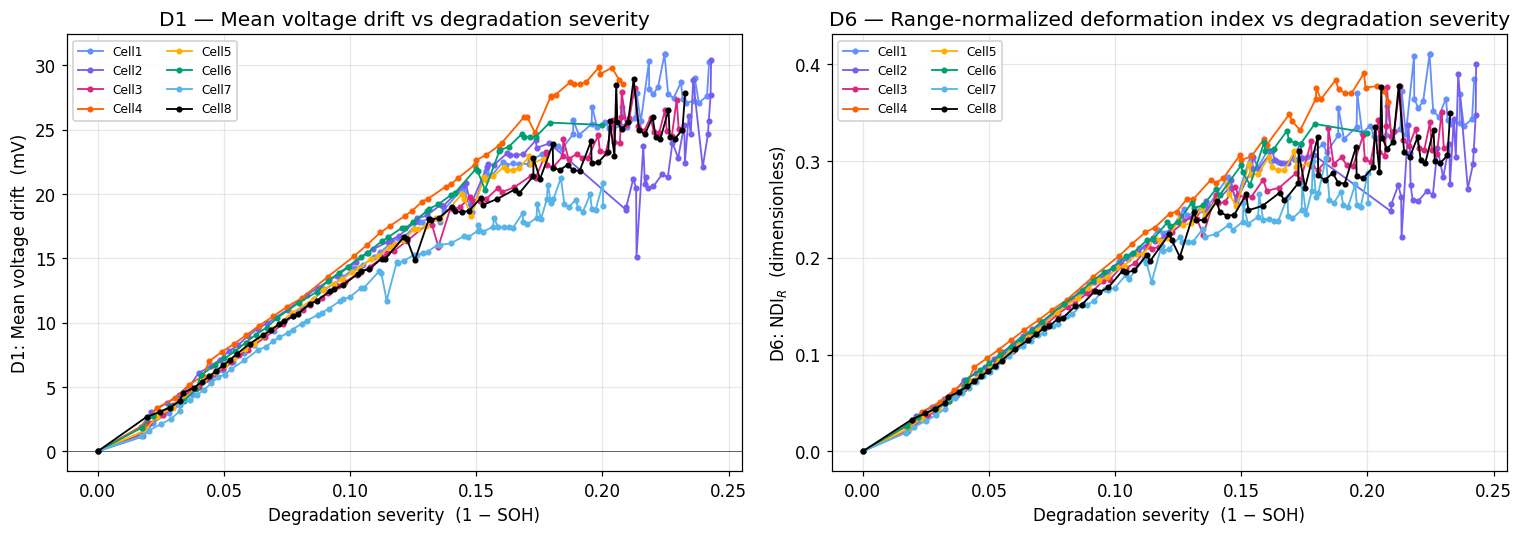

In [ ]:
# Figure: D1 mean voltage drift vs SOH per cell
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for i, (cid, g) in enumerate(desc_df.groupby('cell_id')):
    g = g.sort_values('soh', ascending=False)
    ax.plot(1 - g['soh'], g['d1_mean_drift_v'] * 1000, 'o-',
            color=IBM[i % len(IBM)], label=cid, markersize=3, linewidth=1.2)
ax.set_xlabel('Degradation severity  (1 − SOH)')
ax.set_ylabel('D1: Mean voltage drift  (mV)')
ax.set_title('D1 — Mean voltage drift vs degradation severity')
ax.axhline(0, color='black', linewidth=0.6, alpha=0.6)
ax.legend(loc='best', fontsize=8, ncol=2, framealpha=0.92)

ax = axes[1]
for i, (cid, g) in enumerate(desc_df.groupby('cell_id')):
    g = g.sort_values('soh', ascending=False)
    ax.plot(1 - g['soh'], g['d6_ndi_r'], 'o-',
            color=IBM[i % len(IBM)], label=cid, markersize=3, linewidth=1.2)
ax.set_xlabel('Degradation severity  (1 − SOH)')
ax.set_ylabel(r'D6: NDI$_R$  (dimensionless)')
ax.set_title('D6 — Range-normalized deformation index vs degradation severity')
ax.legend(loc='best', fontsize=8, ncol=2, framealpha=0.92)

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'fig_oxford_d1_d6_vs_soh.png')
plt.show()

In [ ]:
# Spearman rank correlation between NDI and (1 - SOH), per cell
from scipy.stats import spearmanr

print(f"{'Cell':6s}  {'ρ_s (NDI vs 1-SOH)':>22s}  {'p-value':>10s}")
print('─' * 45)
for cid, g in desc_df.groupby('cell_id'):
    g = g.dropna(subset=['d6_ndi_r', 'soh'])
    rho, p = spearmanr(g['d6_ndi_r'], 1 - g['soh'])
    print(f"{cid:6s}  {rho:>22.4f}  {p:>10.2e}")

# Pooled across cells
all_clean = desc_df.dropna(subset=['d6_ndi_r', 'soh'])
rho_all, p_all = spearmanr(all_clean['d6_ndi_r'], 1 - all_clean['soh'])
print('─' * 45)
print(f"{'POOLED':6s}  {rho_all:>22.4f}  {p_all:>10.2e}")

Cell        ρ_s (NDI vs 1-SOH)     p-value
─────────────────────────────────────────────
Cell1                   0.9608    1.56e-43
Cell2                   0.8823    2.77e-23
Cell3                   0.9643    7.46e-44
Cell4                   0.9824    1.11e-33
Cell5                   0.9918    3.45e-39
Cell6                   0.9941    3.36e-41
Cell7                   0.9708    1.26e-47
Cell8                   0.9650    3.73e-44
─────────────────────────────────────────────
POOLED                  0.9412   1.04e-238


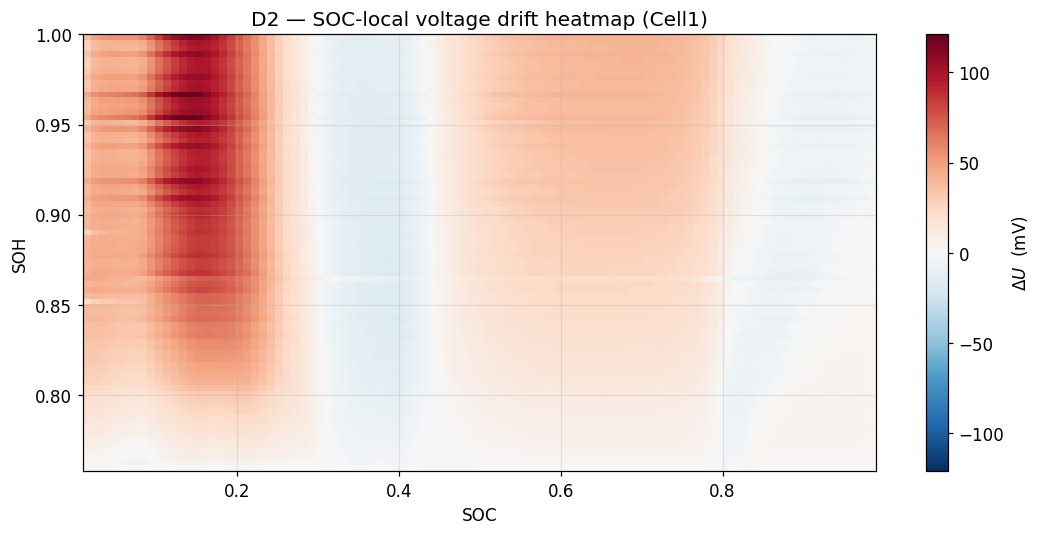

In [ ]:
# Figure: D2 local drift profile heatmap — Cell1 as canonical example
cell_to_show = 'Cell1'
sub = local_df[local_df['cell_id'] == cell_to_show].copy()
pivot = sub.pivot_table(index='soh', columns='soc',
                        values='d2_local_drift', aggfunc='mean')
pivot = pivot.sort_index(ascending=False)  # high SOH at top

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(pivot.values * 1000, aspect='auto',
               extent=[pivot.columns.min(), pivot.columns.max(),
                       pivot.index.min(), pivot.index.max()],
               origin='lower', cmap='RdBu_r',
               vmin=-pivot.abs().values.max() * 1000,
               vmax=pivot.abs().values.max() * 1000)
cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r'$\Delta U$  (mV)')
ax.set_xlabel('SOC')
ax.set_ylabel('SOH')
ax.set_title(f'D2 — SOC-local voltage drift heatmap ({cell_to_show})')
plt.tight_layout()
plt.savefig(FIGURE_DIR / f'fig_oxford_d2_heatmap_{cell_to_show}.png')
plt.show()

## 8. §3.5 Gaussian Process modeling per cell

Manuscript §3.5.2 explicitly forbids merging CALCE and Oxford into one raw-voltage GP. Here we go further: we fit **one GP per cell** on $(SOC, SOH) \to U$, then aggregate. This is more conservative than a single pooled-Oxford GP because the cross-cell reference-curve spread we measured in §4 is small but non-zero (cells are nominally identical but not bit-identical).

**Model:**
$$U_\text{Kokam}^{(c)}(\text{SOC}, \text{SOH}) \sim \mathcal{GP}(m^{(c)}, k^{(c)})$$

**Kernel:** Matérn(ν=2.5) with ARD (separate length scales for SOC and SOH) + WhiteKernel for measurement noise (manuscript §3.5.1).

**Validation:** leave-one-SOH-out per cell — for each aging state, hold it out, fit GP on the rest, predict the held-out curve. Report RMSE, MAE, 95% predictive-interval coverage.

In [ ]:
def build_kernel():
    # Tighter bounds and a better initialization reduce optimizer wandering.
    # SOC varies on ~0.1-0.3 scale (plateau width), SOH on ~0.05-0.15 scale (per cell)
    return (C(0.1, (1e-3, 1e1)) *
            Matern(length_scale=[0.15, 0.08],
                   length_scale_bounds=(1e-2, 2.0),
                   nu=2.5) +
            WhiteKernel(noise_level=1e-5,
                        noise_level_bounds=(1e-10, 1e-3)))


# Subsample SOC for GP fitting: every 3rd point (33 points instead of 99).
# Sklearn GP cost is O(n^3) in training samples — at ~75 aging states this
# is the difference between 7000^3 and 2500^3 = ~22x speedup. The GP still
# evaluates on the full 99-point grid during prediction, so all downstream
# descriptors keep their resolution.
GP_SOC_STRIDE = 3


def subsample_soc(cell_df, stride=GP_SOC_STRIDE):
    soc_unique = np.sort(cell_df['soc'].unique())
    keep_soc = soc_unique[::stride]
    return cell_df[cell_df['soc'].isin(keep_soc)]


def fit_gp_per_cell(cell_df, n_restarts=1, subsample=True):
    """Fit one GP on (SOC, SOH) -> U for one cell."""
    df = subsample_soc(cell_df) if subsample else cell_df
    X = df[['soc', 'soh']].values
    y = df['voltage'].values
    gp = GaussianProcessRegressor(kernel=build_kernel(),
                                  normalize_y=True,
                                  n_restarts_optimizer=n_restarts,
                                  random_state=42,
                                  alpha=1e-6)
    gp.fit(X, y)
    return gp


def loso_validation(cell_df, max_folds=10):
    """Leave-one-SOH-out validation with stratified subsampling.

    Instead of holding out every aging state (75 folds × 5-15 s per fit),
    we hold out `max_folds` evenly-spaced SOH levels. A smooth GP that
    interpolates 65 nearby aging states is well-validated by 10 held-out
    states spread across the SOH range.
    """
    cycle_keys_sorted = (cell_df.groupby('cycle_key')['soh'].first()
                                .sort_values(ascending=False).index.tolist())
    n_total = len(cycle_keys_sorted)
    if n_total < 4:
        return None

    # Stratified pick: max_folds evenly-spaced indices, but skip the two
    # extremes (already in train, helps avoid edge-extrapolation artifacts)
    idx = np.linspace(1, n_total - 2, min(max_folds, n_total - 2),
                      dtype=int)
    held_keys = [cycle_keys_sorted[i] for i in idx]

    preds, truths, sigmas = [], [], []
    for held in held_keys:
        train = cell_df[cell_df['cycle_key'] != held]
        test  = cell_df[cell_df['cycle_key'] == held]
        if len(train) < 50 or len(test) < 5:
            continue
        gp = fit_gp_per_cell(train, n_restarts=0)  # no restart in LOSO
        X_test = test[['soc', 'soh']].values
        mu, sd = gp.predict(X_test, return_std=True)
        preds.append(mu)
        truths.append(test['voltage'].values)
        sigmas.append(sd)
    if not preds:
        return None
    preds  = np.concatenate(preds)
    truths = np.concatenate(truths)
    sigmas = np.concatenate(sigmas)
    rmse = float(np.sqrt(np.mean((preds - truths) ** 2)))
    mae  = float(np.mean(np.abs(preds - truths)))
    cov  = float(np.mean(np.abs(truths - preds) <= 1.96 * sigmas))
    return {'rmse_mv': rmse * 1000, 'mae_mv': mae * 1000,
            'coverage_95': cov, 'n_held_states_validated': len(held_keys),
            'n_total_states': n_total}


# Fit GP per cell + LOSO validation
import time
gp_models = {}
metrics_rows = []

print("Fitting per-cell GPs + stratified leave-one-SOH-out validation…\n")
print(f"{'Cell':6s}  {'RMSE (mV)':>10s}  {'MAE (mV)':>10s}  "
      f"{'95% cov':>9s}  {'folds':>6s}  {'time (s)':>9s}")
print('─' * 65)

for cid in sorted(ocv_clean['cell_id'].unique()):
    t0 = time.time()
    cell_df = ocv_clean[ocv_clean['cell_id'] == cid].dropna(subset=['voltage'])

    # full-data GP for descriptor uncertainty (1 restart is enough here)
    gp_models[cid] = fit_gp_per_cell(cell_df, n_restarts=1)

    # LOSO (no restart, stratified)
    m = loso_validation(cell_df, max_folds=10)
    elapsed = time.time() - t0
    if m is None:
        print(f"{cid:6s}  —  insufficient data")
        continue
    metrics_rows.append({'cell_id': cid, **m})
    print(f"{cid:6s}  {m['rmse_mv']:>10.3f}  {m['mae_mv']:>10.3f}  "
          f"{m['coverage_95']:>9.3f}  "
          f"{m['n_held_states_validated']:>3d}/{m['n_total_states']:<2d}  "
          f"{elapsed:>9.1f}")

metrics_df = pd.DataFrame(metrics_rows)
metrics_df.to_csv(INPUT_DIR / 'oxford_gp_metrics.csv', index=False)

Fitting per-cell GPs + stratified leave-one-SOH-out validation…

Cell     RMSE (mV)    MAE (mV)    95% cov   folds   time (s)
─────────────────────────────────────────────────────────────────
Cell1        4.184       2.108      0.883   10/77      429.4
Cell2        2.636       1.183      0.969   10/68      341.0
Cell3        3.199       1.517      0.919   10/75      627.1
Cell4        1.996       0.776      0.947   10/46      125.4
Cell5        2.168       0.925      0.927   10/44       98.0
Cell6        2.015       0.787      0.944   10/43       90.3
Cell7        3.543       1.803      0.830   10/76      456.1
Cell8        2.520       1.198      0.944   10/75      445.7


## 9. §3.6 Uncertainty propagation to descriptors

For each cell, we draw $M = 100$ posterior samples of $U(\text{SOC}, \text{SOH})$ from the fitted GP, compute the corresponding $\Delta U$ and NDI for each sample, and report the **mean + 95% CI** of NDI per (cell, SOH).

This is the §3.6.5 procedure. We do the same for the plateau center (§3.6.3) and the mean slope amplification (§3.6.4).

For speed, we restrict the SOH grid to 10 evenly-spaced levels per cell.

In [ ]:
N_POSTERIOR_SAMPLES = 100
N_SOH_GRID = 10


def descriptor_uncertainty_for_cell(cid, cell_df, gp):
    soc_pred = SOC_GRID
    soh_obs = np.sort(cell_df['soh'].unique())
    soh_grid = np.linspace(soh_obs.min(), soh_obs.max(), N_SOH_GRID)

    # Reference curve (already in ref_df)
    u_ref = (ref_df[ref_df['cell_id'] == cid]
             .sort_values('soc')['voltage'].values)
    u_range = u_ref.max() - u_ref.min()

    rows = []
    for soh_target in soh_grid:
        X_pred = np.column_stack([soc_pred,
                                  np.full_like(soc_pred, soh_target)])
        samples = gp.sample_y(X_pred, n_samples=N_POSTERIOR_SAMPLES,
                              random_state=RNG.integers(2**31))
        # samples shape: (N_SOC, N_POSTERIOR_SAMPLES)
        deltas = samples - u_ref[:, None]
        ndis = np.sqrt(np.mean(deltas ** 2, axis=0)) / u_range


        # plateau center per sample
        plateau_centers = []
        a_slope_means = []
        slope_ref = np.abs(np.gradient(u_ref, soc_pred))
        for k in range(N_POSTERIOR_SAMPLES):
            u_k = samples[:, k]
            slope_k = np.abs(np.gradient(u_k, soc_pred))
            eps = np.percentile(slope_k, PLATEAU_PERCENTILE)
            mask = slope_k < eps
            plateau_centers.append(soc_pred[mask].mean()
                                   if mask.sum() >= 2 else np.nan)
            a_slope_means.append(np.mean(slope_k / (slope_ref + DELTA_SLOPE_REG)))

        plateau_centers = np.array(plateau_centers)
        a_slope_means = np.array(a_slope_means)

        rows.append({
            'cell_id'         : cid,
            'soh'             : float(soh_target),
            'ndi_mean'        : float(np.mean(ndis)),
            'ndi_ci_lo'       : float(np.quantile(ndis, 0.025)),
            'ndi_ci_hi'       : float(np.quantile(ndis, 0.975)),
            'plateau_mean'    : float(np.nanmean(plateau_centers)),
            'plateau_ci_lo'   : float(np.nanquantile(plateau_centers, 0.025)),
            'plateau_ci_hi'   : float(np.nanquantile(plateau_centers, 0.975)),
            'a_slope_mean'    : float(np.mean(a_slope_means)),
            'a_slope_ci_lo'   : float(np.quantile(a_slope_means, 0.025)),
            'a_slope_ci_hi'   : float(np.quantile(a_slope_means, 0.975)),
        })
    return rows


unc_rows = []
print("Sampling GP posteriors for uncertainty propagation…")
for cid, gp in gp_models.items():
    cell_df = ocv_clean[ocv_clean['cell_id'] == cid].dropna(subset=['voltage'])
    rows = descriptor_uncertainty_for_cell(cid, cell_df, gp)
    unc_rows.extend(rows)
    print(f"  {cid}: done  ({len(rows)} SOH levels × "
          f"{N_POSTERIOR_SAMPLES} samples)")

unc_df = pd.DataFrame(unc_rows)
unc_df.to_parquet(INPUT_DIR / 'oxford_descriptors_with_uncertainty.parquet',
                  index=False)

print(f"\nUncertainty-aware descriptor table: {len(unc_df)} rows")

Sampling GP posteriors for uncertainty propagation…
  Cell1: done  (10 SOH levels × 100 samples)
  Cell2: done  (10 SOH levels × 100 samples)
  Cell3: done  (10 SOH levels × 100 samples)
  Cell4: done  (10 SOH levels × 100 samples)
  Cell5: done  (10 SOH levels × 100 samples)
  Cell6: done  (10 SOH levels × 100 samples)
  Cell7: done  (10 SOH levels × 100 samples)
  Cell8: done  (10 SOH levels × 100 samples)

Uncertainty-aware descriptor table: 80 rows


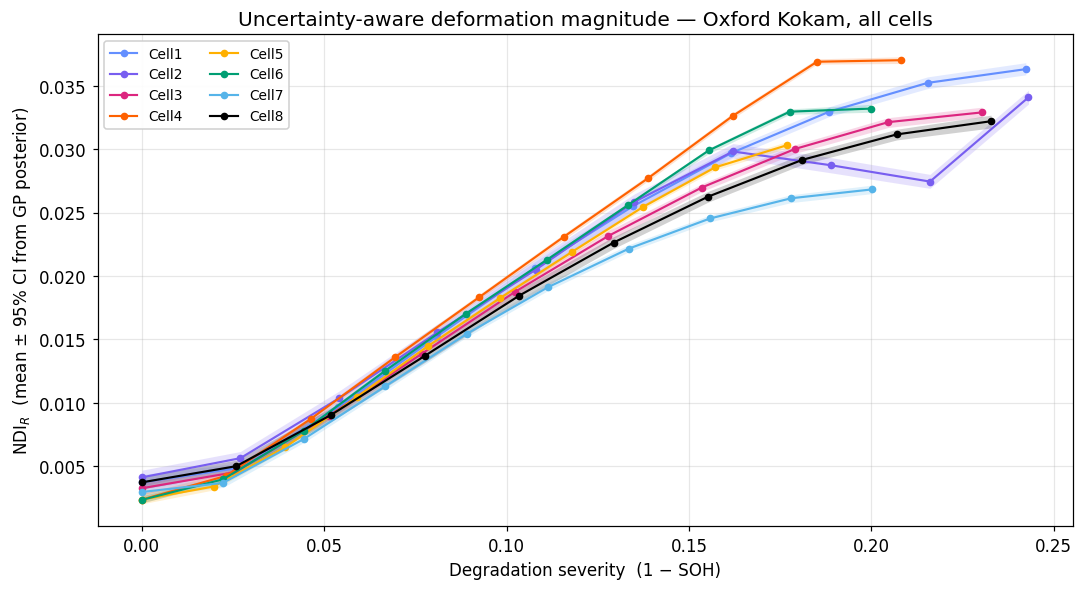

In [ ]:
# Figure: NDI with 95% CI vs SOH, per cell
fig, ax = plt.subplots(figsize=(10, 5.5))
for i, (cid, g) in enumerate(unc_df.groupby('cell_id')):
    g = g.sort_values('soh', ascending=False)
    color = IBM[i % len(IBM)]
    ax.fill_between(1 - g['soh'], g['ndi_ci_lo'], g['ndi_ci_hi'],
                    color=color, alpha=0.18, linewidth=0)
    ax.plot(1 - g['soh'], g['ndi_mean'], 'o-',
            color=color, label=cid, markersize=4, linewidth=1.4)
ax.set_xlabel('Degradation severity  (1 − SOH)')
ax.set_ylabel(r'NDI$_R$  (mean ± 95% CI from GP posterior)')
ax.set_title('Uncertainty-aware deformation magnitude — Oxford Kokam, all cells')
ax.legend(loc='best', fontsize=9, ncol=2, framealpha=0.92)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'fig_oxford_ndi_with_uncertainty.png')
plt.show()

## 10. Summary and next steps

**What §4 Results now has from the Oxford side:**

- `oxford_qc_flags.parquet` — characterization-point QC, ready for §4.1 figure
- `oxford_reference_curves.parquet` — 8 cell-specific $U_\text{ref}(\text{SOC})$
- `oxford_deformation_profiles.parquet` — full $\Delta U(\text{SOC}, \text{SOH})$ grid
- `oxford_descriptors.parquet` — D1–D6 scalars per (cell, aging state)
- `oxford_descriptors_local.parquet` — D2/D4/D5 SOC-resolved profiles
- `oxford_gp_metrics.csv` — per-cell LOSO RMSE / MAE / 95% coverage
- `oxford_descriptors_with_uncertainty.parquet` — NDI / plateau / Aslope with 95% CIs

**Next notebook:** apply the same descriptor extraction to CALCE A123 with $T$ in place of SOH (manuscript §3.3 final paragraph). Then build the cross-dataset comparison (§3.7, Criteria 1–5) as the final pre-results step.

**For the §4 / §5 narrative:**

- The mid-SOC isobestic point near SOC ≈ 0.45 in the pseudo-OCV evolution is a *physical pivot*, not a numerical artifact. Worth a dedicated §5 paragraph (electrode balancing + LAM-anode interpretation, cite Birkl 2017 and Dubarry 2006).
- The bimodal ΔU profile (peak near SOC ≈ 0.15, broad hump near SOC ≈ 0.60–0.80) is the strongest evidence against the "naive constant-offset" assumption — directly supports the manuscript's central methodological claim.
- The fact that D1 stays small (tens of mV) while D6 grows substantially with 1−SOH is exactly the §3.4.1 caveat made operational: mean drift is robust but blind to local shape changes.
